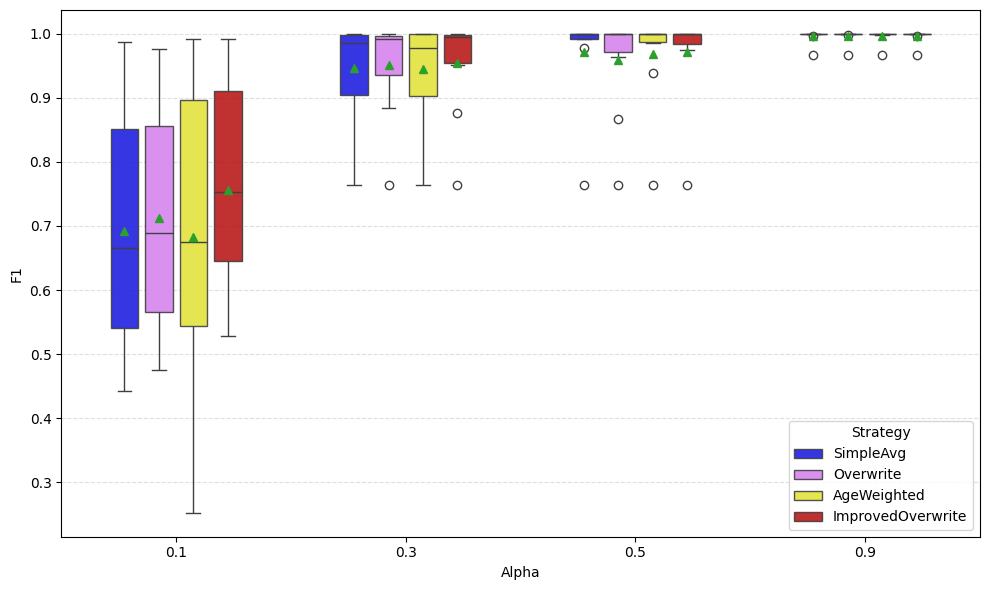

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os

alphas_cycle = [1, 3, 5, 9]
#alphas = [0.1, 0.3, 0.5, 0.9]
strategies = ['SimpleAvg', 'Overwrite', 'AgeWeighted', 'ImprovedOverwrite']

records = []

for alpha in alphas_cycle:
    for strat in strategies:
        #filename = f"f1scoresW_{strat}_alpha{alpha}.txt"
        filename = Path(f"Aggregators/{strat}") / f"f1scoresW_{strat}_alpha{alpha}.txt"
        if not os.path.exists(filename):
            print(f"File mancante: {filename}")
            continue

        with open(filename, 'r') as f:
            content = f.read().strip()
            try:
                values = ast.literal_eval(content)
            except Exception as e:
                raise ValueError(f"Errore parsing {filename}: {e}")

        for v in values:
            records.append({'alpha': f"0.{alpha}", 'Strategy': strat, 'f1': v})

df = pd.DataFrame(records)
palette = {"SimpleAvg": "#0000FF", 
           'Overwrite': "#DF73FF", 
           'AgeWeighted': "#FEFE22", 
           'ImprovedOverwrite': "#D40000"}

plt.figure(figsize=(10,6))
sns.boxplot(x='alpha', y='f1', hue='Strategy', data=df,
            showfliers=True, width=0.6,
            linewidth=1, showmeans=True,
            boxprops=dict(alpha=0.9), 
            gap=0.2, palette=palette)

means = df.groupby(['alpha', 'Strategy'])['f1'].mean().reset_index()
#sns.lineplot(data=means, x='alpha', y='f1', hue='Strategy',
#             marker='o', linewidth=2, legend=False, palette=palette)

plt.xlabel('Alpha')
plt.ylabel('F1')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(Path(f"Aggregators") / "plot_comparison.png")
plt.show()

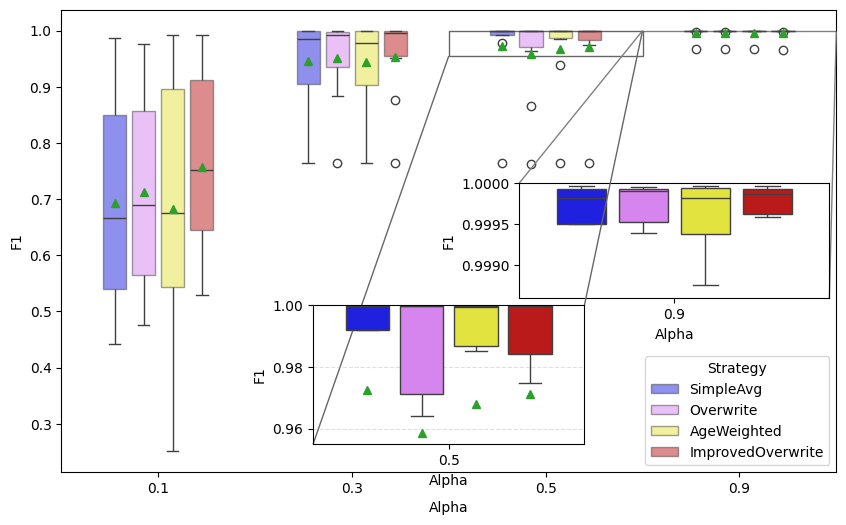

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


alphas_cycle = [1, 3, 5, 9]
#alphas = [0.1, 0.3, 0.5, 0.9]
strategies = ['SimpleAvg', 'Overwrite', 'AgeWeighted', 'ImprovedOverwrite']

records = []

for alpha in alphas_cycle:
    for strat in strategies:
        #filename = f"f1scoresW_{strat}_alpha{alpha}.txt"
        filename = Path(f"Aggregators/{strat}") / f"f1scoresW_{strat}_alpha{alpha}.txt"
        if not os.path.exists(filename):
            print(f"File mancante: {filename}")
            continue

        with open(filename, 'r') as f:
            content = f.read().strip()
            try:
                values = ast.literal_eval(content)
            except Exception as e:
                raise ValueError(f"Errore parsing {filename}: {e}")

        for v in values:
            records.append({'alpha': f"0.{alpha}", 'Strategy': strat, 'f1': v})

df = pd.DataFrame(records)
palette = {"SimpleAvg": "#0000FF", 
           'Overwrite': "#DF73FF", 
           'AgeWeighted': "#FEFE22", 
           'ImprovedOverwrite': "#D40000"}

plt.figure(figsize=(10,6))
sns.boxplot(x='alpha', y='f1', hue='Strategy', data=df,
            showfliers=True, width=0.6,
            linewidth=1, showmeans=True,
            boxprops=dict(alpha=0.5), 
            palette=palette,
            gap=0.2)
plt.ylabel('F1')
plt.xlabel('Alpha')


ax = plt.gca()
axins = inset_axes(ax, width="40%", height="25%", loc='center right')
sns.boxplot(x='alpha', y='f1', hue='Strategy', data=df, ax=axins, 
            showfliers=False, legend=False, gap=0.2, showmeans=True, palette=palette)
axins.set_xlim(2.5, 3.5)
axins.set_ylim(0.9986, 1.0)
axins.set_xlabel('Alpha')
axins.set_ylabel('F1')
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

axins2 = inset_axes(ax, width="35%", height="30%", loc='lower center', borderpad=2)
sns.boxplot(x='alpha', y='f1', hue='Strategy', data=df, ax=axins2,
            showfliers=False, legend=False, gap=0.2, showmeans=True, palette=palette)
axins2.set_xlim(1.5, 2.5)
axins2.set_ylim(0.955, 1.0)
axins.set_ylabel('F1')
mark_inset(ax, axins2, loc1=1, loc2=3, fc="none", ec="0.4")


means = df.groupby(['alpha', 'Strategy'])['f1'].mean().reset_index()
#sns.lineplot(data=means, x='alpha', y='f1', hue='Strategy',
#             marker='o', linewidth=2, legend=False)

plt.xlabel('Alpha')
plt.ylabel('F1')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
#plt.tight_layout()
plt.savefig(Path(f"Aggregators") / "plot_comparison_zoom.png")
plt.show()